# DINO의 가중 k-NN 분류식을 손으로 따라가기

$$
\hat{y}(x) = \arg\max_c \sum_{i\in\mathcal{N}_k(x)}
\mathbb{1}[y_i = c]\cdot\exp\!\left(\frac{\cos(z_x, z_i)}{T}\right),
\qquad T = 0.07
$$

이 노트북은 위 식을 **2차원 합성 데이터**로 한 줄씩 재현한다. 2차원이면 특징 벡터를
단위원 위의 점으로 그릴 수 있어 "코사인 유사도 = 각도"라는 직관이 눈에 보인다.

순서:

1. 3클래스 2D 데이터 → L2 정규화 (단위원)
2. 쿼리 하나에 대해 $\cos$ → top-$k$ → $\exp(\cos/T)$ → 클래스별 합 → $\arg\max$ 를 단계별 출력
3. `eval_knn.py` 의 `knn_classifier` 를 **그대로 옮긴** 구현과 결과 일치 확인
4. $T = 0.01 / 0.07 / 0.12 / 0.15 / 1.0 / \infty$(다수결) 로 예측이 뒤집히는 경계 사례
5. $k$ 스윕 정확도 표
6. plotly 시각화 → `expy.png` 저장

필요 패키지: numpy, torch, plotly, kaleido

In [1]:
# 필요 패키지: numpy, torch, plotly(+kaleido)
import os
import numpy as np
import torch

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_printoptions(precision=4, sci_mode=False, linewidth=140)

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__, "| 저장 위치:", HERE)

torch 2.4.0+cu121 | 저장 위치: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/f7b0ef12-6bf2-432b-b96e-84d30d335283


## 1. 3클래스 2D 특징 데이터 — 그리고 L2 정규화

클래스마다 고유한 "방향"이 있고, 샘플은 그 방향 주변에 각도 잡음을 가지고 흩어진다.
반지름(벡터 길이)은 일부러 제각각으로 뽑는다 — 코사인 유사도가 길이를 무시한다는 걸
확인하기 위해서다.

정규화 $\tilde z = z / \lVert z \rVert$ 를 하면 $\lVert \tilde z\rVert = 1$ 이므로

$$\cos(z_x, z_i) = \frac{z_x \cdot z_i}{\lVert z_x\rVert \lVert z_i\rVert} = \tilde z_x \cdot \tilde z_i$$

**분모가 사라지고 코사인 유사도가 그냥 내적이 된다.** DINO의 `eval_knn.py` 가
`F.normalize` 후 `torch.mm` 한 번으로 끝내는 이유가 이것이다.

In [2]:
NUM_CLASSES = 3
CLASS_DIRS_DEG = np.array([20.0, 140.0, 260.0])   # 클래스별 중심 방향
ANGLE_STD_DEG = 38.0                              # 방향 잡음 (클수록 클래스가 겹침)


def make_features(n_per_class, rng):
    """각 클래스 중심 방향 주변에 점을 뿌리고 L2 정규화해서 반환."""
    zs, ys = [], []
    for c, mu in enumerate(CLASS_DIRS_DEG):
        ang = np.deg2rad(rng.normal(mu, ANGLE_STD_DEG, n_per_class))
        rad = rng.uniform(0.4, 2.5, n_per_class)          # 길이는 제각각
        zs.append(np.stack([rad * np.cos(ang), rad * np.sin(ang)], axis=1))
        ys.append(np.full(n_per_class, c))
    z = np.concatenate(zs).astype(np.float32)
    y = np.concatenate(ys).astype(np.int64)
    perm = rng.permutation(len(y))
    return z[perm], y[perm]


rng = np.random.default_rng(SEED)
z_train_raw, y_train = make_features(40, rng)     # train 120장
z_test_raw, y_test = make_features(70, rng)       # test 210장 (>=100: eval_knn chunk 버그 회피)

# L2 정규화: 이후 내적 = 코사인 유사도
train_features = torch.from_numpy(z_train_raw)
train_features = torch.nn.functional.normalize(train_features, dim=-1, p=2)
test_features = torch.nn.functional.normalize(torch.from_numpy(z_test_raw), dim=-1, p=2)
train_labels = torch.from_numpy(y_train)
test_labels = torch.from_numpy(y_test)

print("train:", tuple(train_features.shape), "test:", tuple(test_features.shape))
print("정규화 전 길이 (앞 5개):", np.linalg.norm(z_train_raw[:5], axis=1).round(4))
print("정규화 후 길이 (앞 5개):", train_features[:5].norm(dim=-1).numpy().round(4))

train: (120, 2) test: (210, 2)
정규화 전 길이 (앞 5개): [0.9075 1.1058 2.0971 1.293  1.1667]
정규화 후 길이 (앞 5개): [1. 1. 1. 1. 1.]


## 2. 쿼리 하나를 식대로 손으로 계산

테스트 이미지 한 장 $x$를 골라 다섯 단계를 그대로 밟는다.

| 단계 | 수식 | 코드 |
|---|---|---|
| (1) | $\cos(z_x, z_i)$ | `test_features[q] @ train_features.t()` |
| (2) | $\mathcal{N}_k(x)$ | `sim.topk(k)` |
| (3) | $\exp(\cos/T)$ | `(d / T).exp()` |
| (4) | $\sum_i \mathbb{1}[y_i=c]\cdot w_i$ | `zeros(C).scatter_add_(0, nb_labels, w)` |
| (5) | $\arg\max_c$ | `probs.argmax()` |

In [3]:
K = 10
T = 0.07
q = 25  # 쿼리로 쓸 test 인덱스 (일부러 클래스 경계 근처 — 이웃이 5:5로 갈린다)

zx = test_features[q]                                   # (2,)
sim = zx @ train_features.t()                           # (1) cos(z_x, z_i), (120,)
d, idx = sim.topk(K, largest=True, sorted=True)         # (2) N_k(x)
nb_labels = train_labels[idx]                           # 이웃들의 y_i
w = (d / T).exp()                                       # (3) exp(cos/T)
probs = torch.zeros(NUM_CLASSES).scatter_add_(0, nb_labels, w)   # (4) 지시함수 + 합
pred = int(probs.argmax())                              # (5) argmax_c

print(f"쿼리 q={q}  참라벨 y={int(test_labels[q])}   z_x = {zx.numpy().round(4)}")
print(f"\n{'순위':>3} {'train_idx':>9} {'y_i':>4} {'cos':>8} {'exp(cos/T)':>13} {'표 점유율':>9}")
for r in range(K):
    print(f"{r+1:>3} {int(idx[r]):>9} {int(nb_labels[r]):>4} "
          f"{float(d[r]):>8.4f} {float(w[r]):>13.1f} {float(w[r]/w.sum())*100:>8.2f}%")
print(f"\n클래스별 표 합 probs = {probs.numpy()}")
print(f"정규화하면          = {(probs/probs.sum()).numpy().round(4)}")
print(f"argmax -> 예측 {pred} / 정답 {int(test_labels[q])} -> {'맞음' if pred==int(test_labels[q]) else '틀림'}")

쿼리 q=25  참라벨 y=0   z_x = [0.2489 0.9685]

 순위 train_idx  y_i      cos    exp(cos/T)     표 점유율
  1        50    0   0.9998     1595623.1    14.46%
  2         9    0   0.9980     1554305.5    14.09%
  3       110    0   0.9945     1478464.1    13.40%
  4        82    1   0.9811     1221826.9    11.07%
  5        71    1   0.9726     1081821.1     9.81%
  6        41    1   0.9624      935544.7     8.48%
  7        19    1   0.9619      929016.1     8.42%
  8        73    0   0.9614      921905.1     8.36%
  9        37    0   0.9421      699452.1     6.34%
 10         7    1   0.9330      614461.6     5.57%

클래스별 표 합 probs = [6249749.5 4782670.5       0. ]
정규화하면          = [0.5665 0.4335 0.    ]
argmax -> 예측 0 / 정답 0 -> 맞음


위 표에서 봐야 할 것: **단순 다수결이면 5 대 5 동점**이다
(클래스 0 이웃 5개: 순위 1·2·3·8·9 / 클래스 1 이웃 5개: 순위 4·5·6·7·10).
다수결 k-NN은 여기서 답을 못 고르고 동점 처리 규칙에 운을 맡긴다.

가중을 넣으면 얘기가 달라진다. 클래스 0이 상위 1~3위($\cos = 0.9998/0.9980/0.9945$)를 독차지하고
클래스 1은 4위($0.9811$)부터 시작하므로, 표 합은 **56.65% : 43.35%** 로 클래스 0이 이긴다 —
참라벨과 일치한다. 동점을 깨는 것은 "몇 명"이 아니라 "얼마나 가까운가"다.

증폭 감각: 1위(0.9998)와 4위(0.9811)는 $\cos$ 이 0.0187 차이인데 표는
$e^{0.0187/0.07} = e^{0.267} \approx 1.31$ 배, 1위와 10위(0.9330)는 0.0668 차이에
$e^{0.954} \approx 2.60$ 배 차이다. 유사도가 다 0.93 이상으로 붙어 있어도 표는 이만큼 벌어진다.

## 3. `eval_knn.py` 의 `knn_classifier` 와 일치하는가

아래는 DINO 원본 `/home/sungwoo/projects/swcho/dino/eval_knn.py` 의 `knn_classifier` 를
**한 줄도 바꾸지 않고 옮긴 것**이다 (`.cuda()` 만 CPU에서 돌도록 device를 따라가게 둔다).
`imgs_per_chunk = num_test_images // 100` 때문에 test가 100장 미만이면 죽으므로,
위에서 test를 210장으로 만들어 두었다.

In [4]:
@torch.no_grad()
def knn_classifier(train_features, train_labels, test_features, test_labels, k, T, num_classes=1000):
    """eval_knn.py:141-179 원본 그대로."""
    top1, top5, total = 0.0, 0.0, 0
    train_features = train_features.t()
    num_test_images, num_chunks = test_labels.shape[0], 100
    imgs_per_chunk = num_test_images // num_chunks
    retrieval_one_hot = torch.zeros(k, num_classes).to(train_features.device)
    for idx in range(0, num_test_images, imgs_per_chunk):
        features = test_features[idx: min((idx + imgs_per_chunk), num_test_images), :]
        targets = test_labels[idx: min((idx + imgs_per_chunk), num_test_images)]
        batch_size = targets.shape[0]

        similarity = torch.mm(features, train_features)
        distances, indices = similarity.topk(k, largest=True, sorted=True)
        candidates = train_labels.view(1, -1).expand(batch_size, -1)
        retrieved_neighbors = torch.gather(candidates, 1, indices)

        retrieval_one_hot.resize_(batch_size * k, num_classes).zero_()
        retrieval_one_hot.scatter_(1, retrieved_neighbors.view(-1, 1), 1)
        distances_transform = distances.clone().div_(T).exp_()
        probs = torch.sum(
            torch.mul(
                retrieval_one_hot.view(batch_size, -1, num_classes),
                distances_transform.view(batch_size, -1, 1),
            ),
            1,
        )
        _, predictions = probs.sort(1, True)

        correct = predictions.eq(targets.data.view(-1, 1))
        top1 = top1 + correct.narrow(1, 0, 1).sum().item()
        top5 = top5 + correct.narrow(1, 0, min(5, k)).sum().item()
        total += targets.size(0)
    top1 = top1 * 100.0 / total
    top5 = top5 * 100.0 / total
    return top1, top5


@torch.no_grad()
def knn_predict_mine(train_features, train_labels, test_features, k, T, num_classes):
    """§2에서 손으로 밟은 다섯 단계를 배치로 확장한 것."""
    sim = test_features @ train_features.t()                 # (1) cos
    d, idx = sim.topk(k, dim=-1, largest=True, sorted=True)  # (2) N_k(x)
    nb = train_labels[idx]                                   # y_i
    w = (d / T).exp()                                        # (3) exp(cos/T)
    probs = torch.zeros(test_features.shape[0], num_classes).scatter_add_(1, nb, w)  # (4)
    return probs.argmax(dim=-1), probs                        # (5)


# 주의: 원본의 top5 줄(`correct.narrow(1, 0, min(5, k))`)은 클래스가 5개 미만이면
# RuntimeError 로 죽는다. 코드를 고치는 대신 num_classes 를 5로 넉넉히 주면
# (클래스 3, 4 는 아무도 안 쓰므로 점수 0) 원본을 한 글자도 안 바꾸고 돌릴 수 있다.
ref_top1, ref_top5 = knn_classifier(train_features, train_labels,
                                    test_features, test_labels,
                                    k=K, T=T, num_classes=5)
mine_pred, mine_probs = knn_predict_mine(train_features, train_labels,
                                         test_features, K, T, NUM_CLASSES)
mine_top1 = (mine_pred == test_labels).sum().item() * 100.0 / len(test_labels)  # 원본과 동일 산술

print(f"eval_knn.knn_classifier : top1 = {ref_top1:.4f}%  (top5 = {ref_top5:.4f}%)")
print(f"직접 구현               : top1 = {mine_top1:.4f}%")
print(f"두 top1 일치? {ref_top1 == mine_top1}  (차이 {abs(ref_top1-mine_top1):.2e})")
print(f"§2 단일 쿼리 probs 재현? {torch.allclose(mine_probs[q], probs)}")

eval_knn.knn_classifier : top1 = 88.0952%  (top5 = 100.0000%)
직접 구현               : top1 = 88.0952%
두 top1 일치? True  (차이 0.00e+00)
§2 단일 쿼리 probs 재현? True


완전히 같다. 원본이 `one_hot × weight` 를 곱해 더하는 것과 `scatter_add_` 는 같은 연산이다.

> **주의**: 원본의 변수명 `distances` 는 **거리가 아니라 유사도**다
> (`largest=True` 로 뽑았고, 곧바로 `div_(T).exp_()` 되어 큰 값이 큰 표가 된다).
> 진짜 거리였다면 먼 이웃이 큰 표를 받는 정반대 식이 된다.

## 4. 온도 $T$ 가 예측을 뒤집는 경계 사례

가중치의 절댓값은 $\arg\max$ 를 바꾸지 않는다 — 두 이웃 사이의 **비율**만 중요하다:

$$\frac{w_1}{w_2} = \exp\!\left(\frac{c_1 - c_2}{T}\right)$$

그래서 $T$ 는 "유사도 차이를 표 차이로 얼마나 증폭할지" 의 다이얼이고,
$T \to \infty$ 극한은 가중치가 전부 1인 **단순 다수결**이다.

아래는 일부러 만든 경계 사례다: $k=10$ 안에

- 클래스 0 이웃 **2개** — 아주 가깝다 ($\cos = 0.95, 0.94$)
- 클래스 1 이웃 **8개** — 어중간하다 ($\cos = 0.80 \sim 0.75$)

표 수로는 1이 8:2 로 이기지만, 유사도로는 0이 압도적이다. $T$ 가 승자를 결정한다.

> 구현 노트: $T = 0.01$ 이면 $e^{0.95/0.01} = e^{95}$ 라 float32가 넘친다.
> 최댓값을 빼고 $\exp((c_i - c_{\max})/T)$ 를 쓰면 모든 표에 같은 상수를 곱한 셈이라
> $\arg\max$ 는 그대로이면서 오버플로가 사라진다 (softmax의 표준 안정화 트릭).

In [5]:
case_cos = torch.tensor([0.95, 0.94, 0.80, 0.79, 0.78, 0.775, 0.77, 0.765, 0.76, 0.75])
case_lab = torch.tensor([0,    0,    1,    1,    1,    1,     1,    1,     1,    1])


def vote(cos, lab, T, num_classes=NUM_CLASSES):
    """T=inf 이면 가중치 1 (단순 다수결). 아니면 exp((cos-max)/T) — 안정화된 exp(cos/T)."""
    w = torch.ones_like(cos) if np.isinf(T) else ((cos - cos.max()) / T).exp()
    p = torch.zeros(num_classes).scatter_add_(0, lab, w)
    return p / p.sum()


print(f"{'T':>8} {'클래스0 점유':>12} {'클래스1 점유':>12}   예측")
for Tv in [0.01, 0.07, 0.12, 0.15, 1.0, np.inf]:
    p = vote(case_cos, case_lab, Tv)
    tag = "  <- DINO 기본값" if Tv == 0.07 else ("  <- 단순 다수결" if np.isinf(Tv) else "")
    print(f"{Tv:>8} {float(p[0]):>11.4f} {float(p[1]):>12.4f}   클래스 {int(p.argmax())}{tag}")

# 뒤집히는 지점을 수치로 찾기
grid = np.geomspace(0.01, 5.0, 4000)
preds = np.array([int(vote(case_cos, case_lab, t).argmax()) for t in grid])
flip = np.where(np.diff(preds) != 0)[0]
print(f"\n예측이 뒤집히는 임계 온도 T* ≈ {grid[flip[0]]:.4f}  "
      f"(T < T* 이면 클래스 0, T > T* 이면 클래스 1)")
print(f"1등끼리만 놓고 푼 근사: 2·exp(0.95/T)=8·exp(0.80/T) -> T*≈0.15/ln4 = {0.15/np.log(4):.4f}")
print("  (실측이 조금 큰 이유: 클래스1 이웃들의 cos가 0.80 아래로 흩어져 유효 표가 줄기 때문)")

       T      클래스0 점유      클래스1 점유   예측
    0.01      1.0000       0.0000   클래스 0
    0.07      0.7387       0.2613   클래스 0  <- DINO 기본값
    0.12      0.5084       0.4916   클래스 0
    0.15      0.4380       0.5620   클래스 1
     1.0      0.2288       0.7712   클래스 1
     inf      0.2000       0.8000   클래스 1  <- 단순 다수결

예측이 뒤집히는 임계 온도 T* ≈ 0.1228  (T < T* 이면 클래스 0, T > T* 이면 클래스 1)
1등끼리만 놓고 푼 근사: 2·exp(0.95/T)=8·exp(0.80/T) -> T*≈0.15/ln4 = 0.1082
  (실측이 조금 큰 이유: 클래스1 이웃들의 cos가 0.80 아래로 흩어져 유효 표가 줄기 때문)


정리하면:

- $T = 0.01$: 1등 이웃이 표를 100% 독식 → 사실상 **1-NN**
- $T = 0.07$: 가까운 2표가 먼 8표를 이긴다 (DINO/Wu et al. 2018의 값)
- $T = 0.15$ 부터 다수결 쪽으로 넘어가고, $T \to \infty$ 면 가중치가 전부 1 → **단순 다수결**, 8:2

경계 $T^*$ 는 손으로도 어림된다: 상위 대표값만으로 클래스별 표가 같아지는 조건
$2e^{0.95/T} = 8e^{0.80/T}$ 를 풀면 $T^* = 0.15/\ln 4 \approx 0.108$.
실측 $0.1228$ 이 조금 큰 이유는 클래스 1 이웃들의 $\cos$ 이 0.80 아래로 흩어져
그쪽 유효 표가 8보다 작아지기 때문이다.

## 5. $k$ 스윕 — $T$ 가 $k$ 민감도를 줄여 준다

`eval_knn.py` 의 기본은 `--nb_knn [10, 20, 100, 200]`. $k$ 를 키우면 관계없는 이웃이 섞이지만,
$\exp(\cos/T)$ 가중이 그 표를 거의 0으로 눌러 버려 정확도가 잘 안 떨어진다.
같은 $k$ 스윕을 **단순 다수결**($T=\infty$)로도 재서 비교한다.

In [6]:
print(f"{'k':>5} {'가중 (T=0.07)':>15} {'단순 다수결':>13}   차이")
rows = []
for kk in [1, 3, 5, 10, 20, 50, 100, 120]:
    pw, _ = knn_predict_mine(train_features, train_labels, test_features, kk, T, NUM_CLASSES)
    acc_w = (pw == test_labels).float().mean().item() * 100
    # 다수결: 가중치 = 1
    sim_all = test_features @ train_features.t()
    _, idx_all = sim_all.topk(kk, dim=-1)
    nb_all = train_labels[idx_all]
    pm = torch.zeros(len(test_labels), NUM_CLASSES).scatter_add_(
        1, nb_all, torch.ones_like(nb_all, dtype=torch.float32)).argmax(-1)
    acc_m = (pm == test_labels).float().mean().item() * 100
    rows.append((kk, acc_w, acc_m))
    print(f"{kk:>5} {acc_w:>14.2f}% {acc_m:>12.2f}%   {acc_w-acc_m:+6.2f}%p")

    k     가중 (T=0.07)        단순 다수결   차이
    1          83.33%        83.33%    +0.00%p
    3          85.24%        85.24%    +0.00%p
    5          87.14%        87.14%    +0.00%p
   10          88.10%        88.10%    +0.00%p
   20          87.14%        88.57%    -1.43%p
   50          87.62%        88.57%    -0.95%p
  100          87.62%        83.81%    +3.81%p
  120          87.62%        33.33%   +54.29%p


세 구간으로 읽힌다.

- **$k$ 가 작을 때(1~5)**: 둘 다 똑같이 낮다(83.3% → 87.1%). 이웃이 적으면 잡음 하나에 답이 흔들린다.
  $k$ 를 키워야 하는 이유다. 이 구간에선 top-$k$ 가 전부 아주 가까운 이웃이라 가중과 다수결의 차이가 없다.
- **중간 구간(10~50)**: 둘 다 87~89% 로 비슷하고, 오히려 다수결이 1%p 정도 앞서기도 한다.
  가중이 항상 이기는 게 아니다 — 이 합성 데이터는 클래스가 대칭적이라 다수결이 불리할 게 없다.
- **$k$ 가 커질 때(100~120)**: 여기서 갈린다. $k=120$ 은 **train 전체**를 이웃으로 삼는 극단이고,
  다수결은 그냥 "클래스 크기 투표"로 전락해 33.3%(= chance)로 붕괴한다.
  반면 가중 k-NN은 87.62% 를 그대로 유지한다.

핵심은 마지막 줄이다. **$\exp(\cos/T)$ 가 사실상 이웃 수를 스스로 고른다** — 먼 이웃의 표를
0에 가깝게 눌러 버리므로 $k$ 를 과하게 잡아도 손해가 없다. 그래서 $k$ 선택이 덜 예민해지고,
`eval_knn.py` 가 `[10, 20, 100, 200]` 를 한 번에 재서 보고해도 무방한 것이다.
실무 기본값이 10~20 인 것은 작은 $k$ 의 분산과 큰 $k$ 의 무의미한 계산 사이의 타협이다.

## 6. 시각화

- **①**: 단위원 위의 train 특징(클래스별 색), 쿼리(★), top-$k$ 이웃은 **마커 크기 = 표의 무게**
  $\exp(\cos/T)$, 연결선 굵기 = 표 점유율. 2차원이라 "코사인 = 각도"가 그대로 보인다.
- **②**: 증폭 곡선 $\exp(\cos/T)$ 위에 이웃 10개를 얹은 것. $\cos$ 이 0.93~1.0 로 좁게 붙어 있어도
  $y$ 값(표의 무게)은 2.6배 벌어진다 — $T=0.07$ 이 하는 일이 이 곡선의 기울기다.
- **③**: §4 경계 사례의 $T$ 별 클래스 점수 막대. $T$ 가 커질수록 다수결(8:2)로 수렴한다.

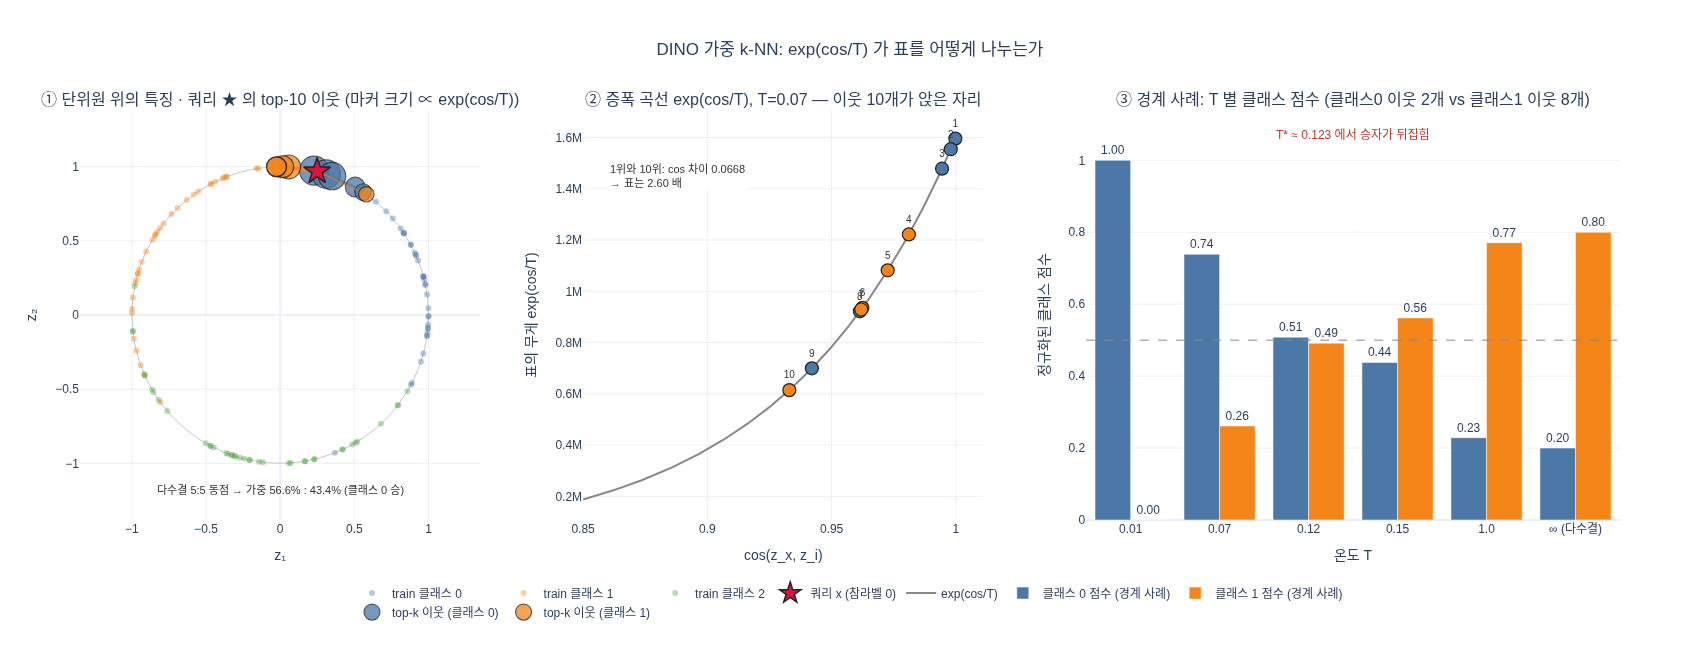

저장: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/f7b0ef12-6bf2-432b-b96e-84d30d335283/expy.png | 370701 bytes


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PALETTE = ["#4C78A8", "#F58518", "#54A24B"]
th = np.linspace(0, 2 * np.pi, 721)
w_np = w.numpy()
share = w_np / w_np.sum()
nb_list = idx.tolist()
nb_set = set(nb_list)

fig = make_subplots(
    rows=1, cols=3, column_widths=[0.30, 0.30, 0.40],
    subplot_titles=(
        f"① 단위원 위의 특징 · 쿼리 ★ 의 top-{K} 이웃 (마커 크기 ∝ exp(cos/T))",
        f"② 증폭 곡선 exp(cos/T), T={T} — 이웃 10개가 앉은 자리",
        "③ 경계 사례: T 별 클래스 점수 (클래스0 이웃 2개 vs 클래스1 이웃 8개)"),
)

# --- ① 단위원 + 가중치 크기 ---
fig.add_trace(go.Scatter(x=np.cos(th), y=np.sin(th), mode="lines",
                         line=dict(color="#c8c8c8", width=1),
                         showlegend=False, hoverinfo="skip"), row=1, col=1)
for c in range(NUM_CLASSES):
    m = np.where(train_labels.numpy() == c)[0]
    others = [t for t in m if t not in nb_set]
    fig.add_trace(go.Scatter(
        x=train_features[others, 0], y=train_features[others, 1], mode="markers",
        marker=dict(size=6, color=PALETTE[c], opacity=0.40),
        name=f"train 클래스 {c}", legendgroup=f"c{c}"), row=1, col=1)
for c in range(NUM_CLASSES):
    ranks = [r for r, t in enumerate(nb_list) if int(train_labels[t]) == c]
    if not ranks:
        continue
    ii = [nb_list[r] for r in ranks]
    for r in ranks:   # 쿼리 -> 이웃 연결선 (굵기 ∝ 표 점유율)
        t = nb_list[r]
        fig.add_trace(go.Scatter(
            x=[float(zx[0]), float(train_features[t, 0])],
            y=[float(zx[1]), float(train_features[t, 1])],
            mode="lines", line=dict(color=PALETTE[c], width=0.6 + 4.0 * share[r] / share.max()),
            opacity=0.45, showlegend=False, hoverinfo="skip"), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=train_features[ii, 0], y=train_features[ii, 1], mode="markers",
        marker=dict(size=[7 + 22 * float(w_np[r] / w_np.max()) for r in ranks],
                    color=PALETTE[c], opacity=0.75, line=dict(color="#222", width=1.2)),
        name=f"top-k 이웃 (클래스 {c})", legendgroup=f"c{c}",
        hovertext=[f"순위 {r+1} · cos={float(d[r]):.4f} · 표 {share[r]*100:.2f}%" for r in ranks],
        hoverinfo="text"), row=1, col=1)
fig.add_trace(go.Scatter(x=[float(zx[0])], y=[float(zx[1])], mode="markers",
                         marker=dict(size=20, color="crimson", symbol="star",
                                     line=dict(color="#222", width=1.5)),
                         name=f"쿼리 x (참라벨 {int(test_labels[q])})"), row=1, col=1)
fig.add_annotation(row=1, col=1, xref="x", yref="y", x=0.0, y=-1.18,
                   text=f"다수결 5:5 동점 → 가중 {float(probs[0]/probs.sum())*100:.1f}% : "
                        f"{float(probs[1]/probs.sum())*100:.1f}% (클래스 0 승)",
                   showarrow=False, font=dict(size=11, color="#333"))

# --- ② 증폭 곡선 ---
cs = np.linspace(0.85, 1.0, 300)
fig.add_trace(go.Scatter(x=cs, y=np.exp(cs / T), mode="lines",
                         line=dict(color="#888", width=2), name="exp(cos/T)"), row=1, col=2)
for c in range(NUM_CLASSES):
    ranks = [r for r, t in enumerate(nb_list) if int(train_labels[t]) == c]
    if not ranks:
        continue
    fig.add_trace(go.Scatter(
        x=[float(d[r]) for r in ranks], y=[float(w_np[r]) for r in ranks],
        mode="markers+text", marker=dict(size=13, color=PALETTE[c],
                                         line=dict(color="#222", width=1.2)),
        text=[f"{r+1}" for r in ranks], textposition="top center",
        textfont=dict(size=10, color="#333"),
        legendgroup=f"c{c}", showlegend=False,
        hovertext=[f"순위 {r+1} · 표 {share[r]*100:.2f}%" for r in ranks],
        hoverinfo="text"), row=1, col=2)
fig.add_annotation(row=1, col=2, xref="x2", yref="y2", x=0.888, y=1.45e6,
                   text=f"1위와 10위: cos 차이 {float(d[0]-d[-1]):.4f}<br>"
                        f"→ 표는 {float(w_np[0]/w_np[-1]):.2f} 배",
                   showarrow=False, align="left", font=dict(size=11, color="#333"),
                   bgcolor="rgba(255,255,255,0.85)")

# --- ③ T별 막대 ---
T_labels = ["0.01", "0.07", "0.12", "0.15", "1.0", "∞ (다수결)"]
T_vals = [0.01, 0.07, 0.12, 0.15, 1.0, np.inf]
scores = np.array([vote(case_cos, case_lab, t).numpy() for t in T_vals])
for c in [0, 1]:
    fig.add_trace(go.Bar(x=T_labels, y=scores[:, c], name=f"클래스 {c} 점수 (경계 사례)",
                         marker_color=PALETTE[c],
                         text=[f"{v:.2f}" for v in scores[:, c]], textposition="outside"),
                  row=1, col=3)
fig.add_hline(y=0.5, line=dict(color="#888", width=1, dash="dash"), row=1, col=3)
fig.add_annotation(row=1, col=3, xref="x3", yref="y3", x=2.5, y=1.07,
                   text=f"T* ≈ {grid[flip[0]]:.3f} 에서 승자가 뒤집힘",
                   showarrow=False, font=dict(size=12, color="#c0392b"))

fig.update_xaxes(range=[-1.35, 1.35], title_text="z₁", row=1, col=1)
fig.update_yaxes(range=[-1.35, 1.35], scaleanchor="x", scaleratio=1, title_text="z₂", row=1, col=1)
fig.update_xaxes(title_text="cos(z_x, z_i)", row=1, col=2)
fig.update_yaxes(title_text="표의 무게 exp(cos/T)", row=1, col=2)
fig.update_xaxes(title_text="온도 T", row=1, col=3)
fig.update_yaxes(title_text="정규화된 클래스 점수", range=[0, 1.14], row=1, col=3)
fig.update_layout(
    title=dict(text="DINO 가중 k-NN: exp(cos/T) 가 표를 어떻게 나누는가", x=0.5),
    barmode="group", template="plotly_white", width=1700, height=650,
    legend=dict(orientation="h", yanchor="bottom", y=-0.26, xanchor="center", x=0.5),
    margin=dict(t=110, b=130),
)

_show(fig)

out_png = os.path.join(HERE, "expy.png")
fig.write_image(out_png, scale=2)
print("저장:", out_png, "|", os.path.getsize(out_png), "bytes")

## 정리

| 수식 항 | 이 노트북에서 확인한 것 |
|---|---|
| $\cos(z_x, z_i)$ | L2 정규화 후 **내적 = 코사인**. 벡터 길이는 무시된다 (§1) |
| $\mathcal{N}_k(x)$ | `topk(k, largest=True)` — 유사도가 큰 순 (§2) |
| $\exp(\cos/T)$ | $T=0.07$ 에서 $\cos$ 0.0668 차이가 표 2.6배 차이 (§2) |
| $\mathbb{1}[y_i=c]\cdot\sum$ | 원-핫 곱셈 = `scatter_add_`, 원본과 top1 완전 일치 (§3) |
| $T$ | $T\to 0$ = 1-NN, $T\to\infty$ = 다수결. 실측 경계 $T^* \approx 0.123$ (§4) |
| $\arg\max_c$ | 표 합이 가장 큰 클래스. 다수결 5:5 동점을 56.65:43.35 로 깬다 (§2) |
| 학습 파라미터 | **0개**. $k$ 와 $T$ 는 고정 하이퍼파라미터일 뿐 (전체) |

$T = 0.07$ 은 Wu et al. 2018, *"Unsupervised Feature Learning via Non-Parametric
Instance Discrimination"* (CVPR 2018)에서 온 값이고, DINO는 `eval_knn.py` 의
`--temperature` 기본값으로 그대로 물려받았다.